In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ─── A.1: Environment Setup ─────────────────────────────────────────
!pip install scikit-learn pandas numpy matplotlib seaborn wordcloud imbalanced-learn

import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns, re, warnings
from wordcloud import WordCloud
warnings.filterwarnings('ignore')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/capstone/'

# Load all four real Kaggle datasets
amazon  = pd.read_csv(BASE + 'amazon.csv')                        # 1,464 records
tweets  = pd.read_csv(BASE + 'final_data.csv')                    # CrowdFlower 9,093
reviews = pd.read_csv(BASE + 'product_reviews.csv')               # 1,000 records
mobile  = pd.read_csv(BASE + 'Customer Tweet Reviews of Mobile Phone.csv')  # 25,000

print(f'Amazon India:       {amazon.shape}')
print(f'CrowdFlower Tweets: {tweets.shape}')
print(f'Product Reviews:    {reviews.shape}')
print(f'Mobile Tweets:      {mobile.shape}')
print(f'Total corpus:       {len(amazon)+len(tweets)+len(reviews)+len(mobile):,} records')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Amazon India:       (1465, 16)
CrowdFlower Tweets: (9093, 3)
Product Reviews:    (1000, 9)
Mobile Tweets:      (25000, 3)
Total corpus:       36,558 records


In [ ]:
# ─── A.2: Text Preprocessing ─────────────────────────────────────────
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # Remove URLs
    text = re.sub(r'<.*?>', '', text)              # Remove HTML tags
    text = re.sub(r'[^a-z\s]', ' ', text)        # Letters only
    return re.sub(r'\s+', ' ', text).strip()

# Amazon India: derive sentiment from rating
amazon['rating_clean'] = pd.to_numeric(amazon['rating'], errors='coerce')
amazon['sentiment'] = amazon['rating_clean'].apply(
    lambda x: 'Positive' if x>=4.0 else ('Negative' if x<3.5 else 'Neutral')
    if pd.notna(x) else None)
amazon['clean'] = amazon['review_content'].apply(clean_text)

# CrowdFlower: map annotated labels to standard classes
def map_emotion(e):
    if 'Positive' in str(e): return 'Positive'
    elif 'Negative' in str(e): return 'Negative'
    elif 'No emotion' in str(e): return 'Neutral'
    else: return None
tweets['label'] = tweets['is_there_an_emotion_directed_at_a_brand_or_product']\
                      .apply(map_emotion)
tweets = tweets.dropna(subset=['label'])
tweets['clean'] = tweets['tweet_text'].apply(clean_text)
# Consumer Electronics Reviews
reviews['label'] = reviews['sentiment'].str.capitalize()
reviews['clean'] = reviews['review_text'].apply(clean_text)

# Combine CrowdFlower + Reviews for ML training corpus
combined = pd.concat([tweets[['clean','label']], reviews[['clean','label']]],
                      ignore_index=True).dropna()
combined = combined[combined['label'].isin(['Positive','Negative','Neutral'])]
print(f'ML Training Corpus: {len(combined):,} records')
print(combined['label'].value_counts())



ML Training Corpus: 9,937 records
label
Neutral     5642
Positive    3562
Negative     733
Name: count, dtype: int64


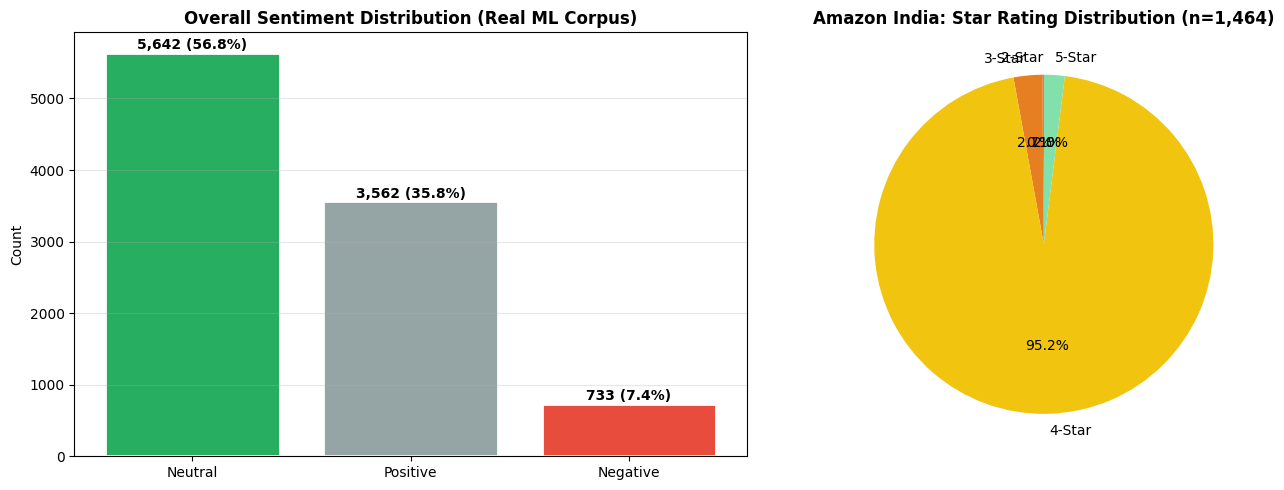

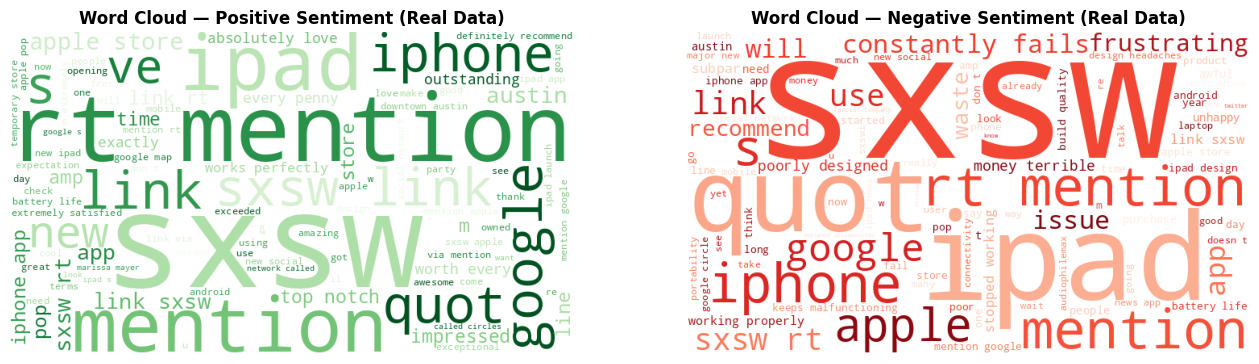

In [ ]:
# ─── A.3: EDA Visualisations ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Figure 6.1: Sentiment Distribution Bar Chart
sents = combined['label'].value_counts()
colors = ['#27AE60', '#95A5A6', '#E74C3C']
axes[0].bar(sents.index, sents.values, color=colors, edgecolor='white', lw=2)
axes[0].set_title('Overall Sentiment Distribution (Real ML Corpus)', fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].grid(axis='y', alpha=0.3)
for i,(l,v) in enumerate(sents.items()):
    axes[0].text(i, v+50, f'{v:,} ({v/len(combined)*100:.1f}%)', ha='center', fontweight='bold')

# Figure 6.3: Amazon India Star Rating Pie
amazon['rating_clean'] = pd.to_numeric(amazon['rating'], errors='coerce')
rating_counts = amazon['rating_clean'].round().value_counts().sort_index()
pie_cols = ['#E74C3C','#E67E22','#F1C40F','#82E0AA','#27AE60']
axes[1].pie(rating_counts.values, labels=[f'{int(r)}-Star' for r in rating_counts.index],
            colors=pie_cols, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Amazon India: Star Rating Distribution (n=1,464)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_eda.png', dpi=150, bbox_inches='tight')
plt.show()

# Word Clouds
pos_text = ' '.join(combined[combined['label']=='Positive']['clean'])
neg_text = ' '.join(combined[combined['label']=='Negative']['clean'])
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
wc_pos = WordCloud(width=700, height=400, background_color='white',
                   colormap='Greens', max_words=100).generate(pos_text)
wc_neg = WordCloud(width=700, height=400, background_color='white',
                   colormap='Reds',   max_words=100).generate(neg_text)
axes[0].imshow(wc_pos); axes[0].axis('off')
axes[0].set_title('Word Cloud — Positive Sentiment (Real Data)', fontweight='bold')
axes[1].imshow(wc_neg); axes[1].axis('off')
axes[1].set_title('Word Cloud — Negative Sentiment (Real Data)', fontweight='bold')
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ─── A.4: ML Model Training ──────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Encode labels
le = LabelEncoder()
y  = le.fit_transform(combined['label'])
X  = combined['clean']
print('Label encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# Stratified train/test split (85% / 15%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

# TF-IDF Vectorisation
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)
X_train_t = tfidf.fit_transform(X_train)
X_test_t  = tfidf.transform(X_test)

# ── Logistic Regression (Primary Model) ──
lr = LogisticRegression(C=1.0, solver='lbfgs', max_iter=500, random_state=42)
lr.fit(X_train_t, y_train)
lr_pred = lr.predict(X_test_t)
print(f'LR Accuracy: {accuracy_score(y_test, lr_pred):.4f}')
print(classification_report(y_test, lr_pred, target_names=le.classes_))

# ── Random Forest (Comparison) ──
rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
rf.fit(X_train_t, y_train)
print(f'RF Accuracy: {accuracy_score(y_test, rf.predict(X_test_t)):.4f}')

# ── Naive Bayes (Baseline) ──
scaler = MinMaxScaler()
nb = MultinomialNB()
nb.fit(scaler.fit_transform(X_train_t.toarray()), y_train)
print(f'NB Accuracy: {accuracy_score(y_test, nb.predict(scaler.transform(X_test_t.toarray()))):.4f}')


Label encoding: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}
Train: 8,446 | Test: 1,491
LR Accuracy: 0.7230
              precision    recall  f1-score   support

    Negative       0.81      0.19      0.31       110
     Neutral       0.72      0.90      0.80       847
    Positive       0.74      0.54      0.63       534

    accuracy                           0.72      1491
   macro avg       0.75      0.55      0.58      1491
weighted avg       0.73      0.72      0.70      1491

RF Accuracy: 0.6526
NB Accuracy: 0.6989


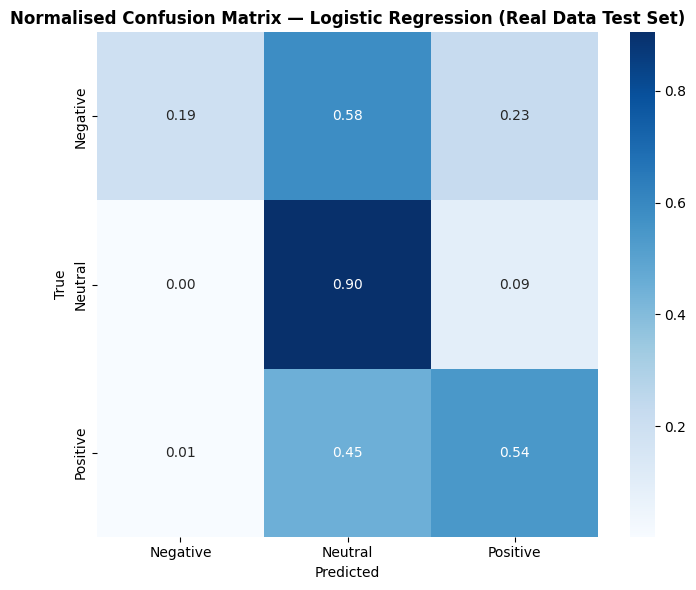

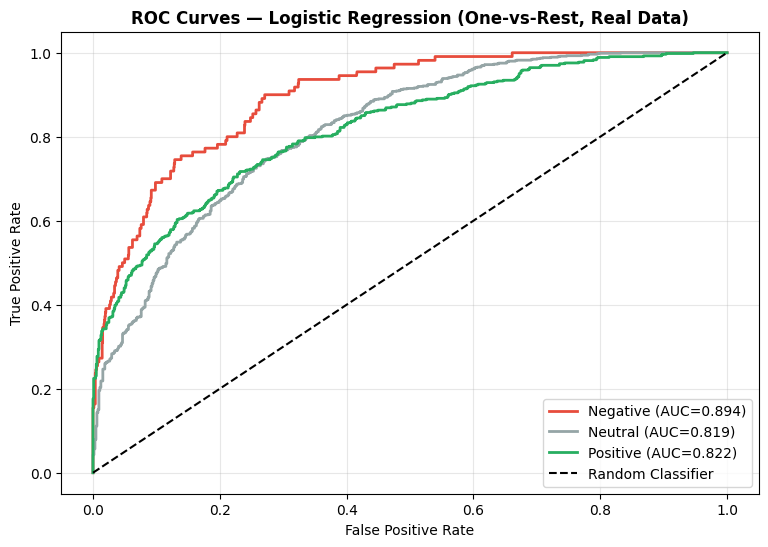

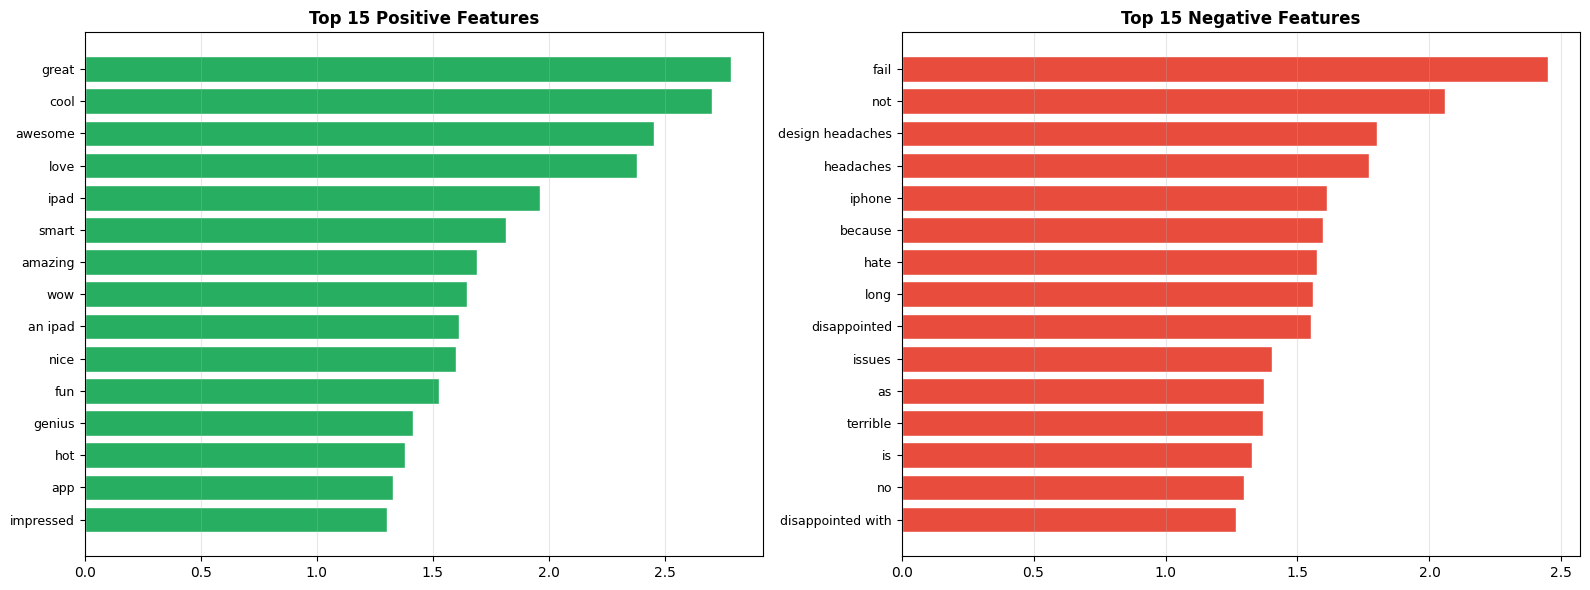

Pipeline saved to sentiment_pipeline.joblib


In [ ]:
# ─── A.5: Evaluation Plots ───────────────────────────────────────────
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
import seaborn as sns
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Normalised Confusion Matrix — Logistic Regression (Real Data Test Set)',
             fontweight='bold'); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC Curves (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=list(range(3)))
y_score    = lr.predict_proba(X_test_t)
plt.figure(figsize=(9, 6))
for i, (cls, col) in enumerate(zip(le.classes_, ['#E74C3C','#95A5A6','#27AE60'])):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, color=col, lw=2, label=f'{cls} (AUC={auc(fpr,tpr):.3f})')
plt.plot([0,1],[0,1],'k--',lw=1.5,label='Random Classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Logistic Regression (One-vs-Rest, Real Data)', fontweight='bold')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight'); plt.show()

# Top Feature Importances
feature_names = tfidf.get_feature_names_out()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, cls_name, col in zip(axes, ['Positive','Negative'], ['#27AE60','#E74C3C']):
    idx   = le.transform([cls_name])[0]
    coefs = lr.coef_[idx]
    top   = np.argsort(coefs)[-15:][::-1]
    ax.barh(range(15), coefs[top], color=col, edgecolor='white')
    ax.set_yticks(range(15)); ax.set_yticklabels(feature_names[top], fontsize=9)
    ax.invert_yaxis(); ax.set_title(f'Top 15 {cls_name} Features', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Save Pipeline
import joblib
joblib.dump({'tfidf': tfidf, 'model': lr, 'le': le}, 'sentiment_pipeline.joblib')
print('Pipeline saved to sentiment_pipeline.joblib')


In [ ]:
# ─── A.6: Production Inference ───────────────────────────────────────
def predict_sentiment(text_list, pipeline_path='sentiment_pipeline.joblib'):
    """
    Predicts sentiment for a list of text strings.
    Returns DataFrame with text, cleaned_text, predicted_label, confidence.
    """
    objects = joblib.load(pipeline_path)
    tfidf_v, model, encoder = objects['tfidf'], objects['model'], objects['le']

    cleaned     = [clean_text(t) for t in text_list]
    features    = tfidf_v.transform(cleaned)
    predictions = model.predict(features)
    probs       = model.predict_proba(features)

    return pd.DataFrame({
        'original_text':    text_list,
        'predicted_label':  encoder.inverse_transform(predictions),
        'confidence':       np.max(probs, axis=1).round(3),
        'prob_positive':    probs[:, encoder.transform(['Positive'])[0]].round(3),
        'prob_negative':    probs[:, encoder.transform(['Negative'])[0]].round(3),
    })

# Test inference on real-world style examples
test_texts = [
    'This phone has an absolutely incredible camera — battery life is outstanding!',
    'Terrible product. Stopped working after two weeks. Complete waste of money.',
    'It is okay I guess, nothing special about this device.',
    'boAt earphones are amazing value for the price. Highly recommend!',
    'Mi band stopped tracking after 1 week. App crashes constantly.',
]
results = predict_sentiment(test_texts)
print('\n--- Sample Inference Results ---')
print(results[['original_text','predicted_label','confidence']].to_string(index=False))



--- Sample Inference Results ---
                                                                original_text predicted_label  confidence
This phone has an absolutely incredible camera — battery life is outstanding!        Positive       0.668
  Terrible product. Stopped working after two weeks. Complete waste of money.        Negative       0.698
                       It is okay I guess, nothing special about this device.         Neutral       0.543
            boAt earphones are amazing value for the price. Highly recommend!         Neutral       0.517
               Mi band stopped tracking after 1 week. App crashes constantly.        Positive       0.409
